In [112]:
import pandas as pd
NewChurnModel = pd.read_csv('credit_card_churn.csv')

#check dtypes and columns
print(NewChurnModel.dtypes)
print(NewChurnModel.columns)

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income

In [113]:
#how many unique customers are in the dataset
NewChurnModel['CLIENTNUM'].nunique()
print("length of dataset:", len(NewChurnModel))
print("number of unique customers:", NewChurnModel['CLIENTNUM'].nunique())


length of dataset: 10127
number of unique customers: 10127


In [114]:
NewChurnModel[['Months_on_book',
               'Months_Inactive_12_mon',
               'Total_Amt_Chng_Q4_Q1',
               'Total_Ct_Chng_Q4_Q1']].describe()

,Months_on_book,Months_Inactive_12_mon,Total_Amt_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,35.928409,2.341167,0.759941,0.712222
std,7.986416,1.010622,0.219207,0.238086
min,13.000000,0.000000,0.000000,0.000000
25%,31.000000,2.000000,0.631000,0.582000
50%,36.000000,2.000000,0.736000,0.702000
75%,40.000000,3.000000,0.859000,0.818000
max,56.000000,6.000000,3.397000,3.714000


In [115]:
#Drop unnecessary columns
NewChurnModel = NewChurnModel.drop(columns=[
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
], errors="ignore")

In [116]:
#check all new columns and dtypes
print(NewChurnModel.dtypes)
print(NewChurnModel.columns)

Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object
Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Cred

In [117]:
#change the dtype of the target variable to numeric
NewChurnModel['Attrition_Flag'] = (
    NewChurnModel['Attrition_Flag']
    .map({
        'Existing Customer': 0,
        'Attrited Customer': 1
    })
)
print(NewChurnModel['Attrition_Flag'].dtype)

int64


In [118]:
#separate the customer characteristic features
customer_characteristics = NewChurnModel[[
    'Customer_Age',
    'Gender',
    'Dependent_count',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category',
    'Attrition_Flag'
]
].copy()

print(customer_characteristics.dtypes)

Customer_Age        int64
Gender             object
Dependent_count     int64
Education_Level    object
Marital_Status     object
Income_Category    object
Card_Category      object
Attrition_Flag      int64
dtype: object


In [119]:
#separate the customer financial features
financial_behavior = NewChurnModel[[
    'Months_on_book',
    'Total_Relationship_Count',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Avg_Open_To_Buy',
    'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio',
    'Attrition_Flag'
]].copy()

print(financial_behavior.dtypes)

Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
Attrition_Flag                int64
dtype: object


In [120]:
combined_features = NewChurnModel.copy()
print(combined_features.dtypes)

Attrition_Flag                int64
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


In [121]:
#check the shape of the datasets
    #21 columns since both have attrition flag
print(customer_characteristics.shape)
print(financial_behavior.shape)
print(combined_features.shape)

(10127, 8)
(10127, 13)
(10127, 20)


In [122]:
#check the first few rows of the datasets
print("Customer Characteristics:")
print(customer_characteristics.head())
print("\nFinancial Behavior:")
print(financial_behavior.head())
print("\nCombined Features:")
print(combined_features.head())

Customer Characteristics:
   Customer_Age Gender  Dependent_count Education_Level Marital_Status  \
0            45      M                3     High School        Married   
1            49      F                5        Graduate         Single   
2            51      M                3        Graduate        Married   
3            40      F                4     High School        Unknown   
4            40      M                3      Uneducated        Married   

  Income_Category Card_Category  Attrition_Flag  
0     $60K - $80K          Blue               0  
1  Less than $40K          Blue               0  
2    $80K - $120K          Blue               0  
3  Less than $40K          Blue               0  
4     $60K - $80K          Blue               0  

Financial Behavior:
   Months_on_book  Total_Relationship_Count  Months_Inactive_12_mon  \
0              39                         5                       1   
1              44                         6                       

In [123]:
#check for churn rate
    #there is definitely a class imbalance in the dataset, with more existing customers than attrited customers
print(combined_features['Attrition_Flag'].value_counts())
print("\nChurn Percentage:")
print(combined_features['Attrition_Flag'].value_counts(normalize=True)*100)

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

Churn Percentage:
Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64


In [124]:
#overall summary statistics of the combined features dataset
combined_features.describe(include='all')

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127,10127.000000,10127,10127,10127,10127,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,NaN,NaN,2,NaN,7,4,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,F,NaN,Graduate,Married,Less than $40K,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5358,NaN,3128,4687,3561,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.160660,46.325960,NaN,2.346203,NaN,NaN,NaN,NaN,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,0.367235,8.016814,NaN,1.298908,NaN,NaN,NaN,NaN,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,0.000000,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,0.000000,41.000000,NaN,1.000000,NaN,NaN,NaN,NaN,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,0.000000,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,0.000000,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000


In [125]:
#confirming no missing values in the dataset
NewChurnModel.isnull().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

/var/folders/63/h0zgkssd48bbn8s4xmhg8hs40000gn/T/ipykernel_31061/1361698361.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Existing Customer', 'Attrited Customer'])


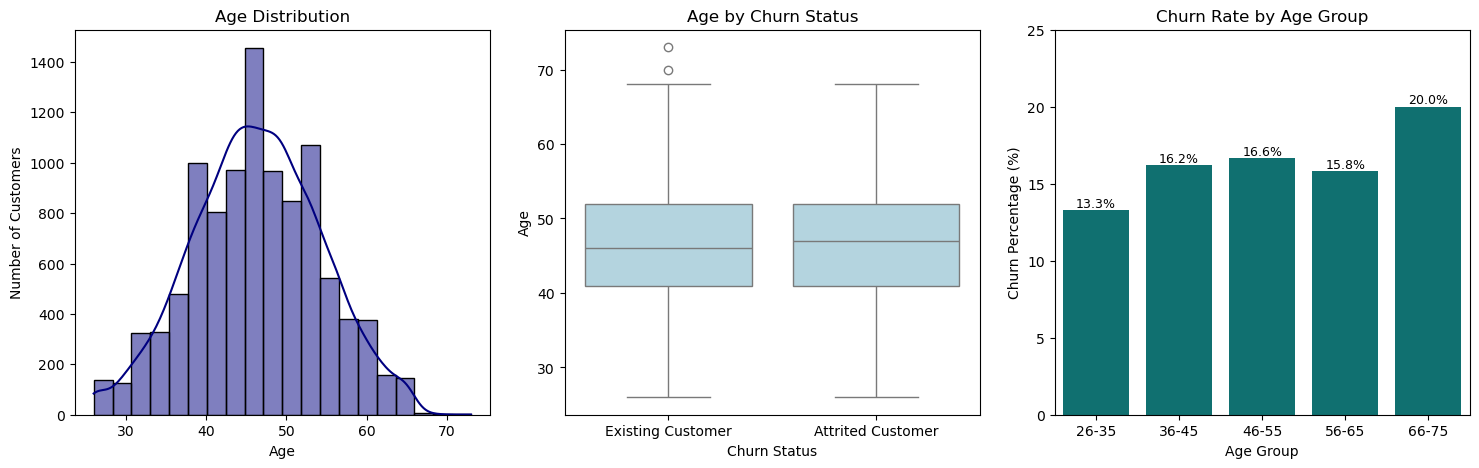

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

#create age groups
customer_characteristics['Age_Group'] = pd.cut(
    customer_characteristics['Customer_Age'],
    bins=[25,35,45,55,65,75],
    labels=['26-35', '36-45', '46-55', '56-65', '66-75']
)
#calculate churn rate by age group
age_churn = pd.crosstab(
    customer_characteristics['Age_Group'],
    customer_characteristics['Attrition_Flag'],
    normalize='index'
)*100

#create figure
fig, axes = plt.subplots(1,3, figsize=(18,5))

#Histogram
sns.histplot(
    data=customer_characteristics,
    x='Customer_Age',
    bins=20,
    kde=True,
    color='navy',
    ax=axes[0]
)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

#boxplot
sns.boxplot(
    data=customer_characteristics,
    x='Attrition_Flag',
    y='Customer_Age',
    color='lightblue',
    ax=axes[1]
)
axes[1].set_title('Age by Churn Status')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Age')

axes[1].set_xticklabels(['Existing Customer', 'Attrited Customer'])

#Churn Percentage by Age Group
sns.barplot(
    x=age_churn.index,
    y=age_churn[1],
    color='teal',
    ax=axes[2]
)
axes[2].set_title('Churn Rate by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Churn Percentage (%)')
axes[2].set_ylim(0, 25)

#Add percentages
for p in axes[2].patches:
    axes[2].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
    )
plt.subplots_adjust(wspace=0.18)
plt.show()

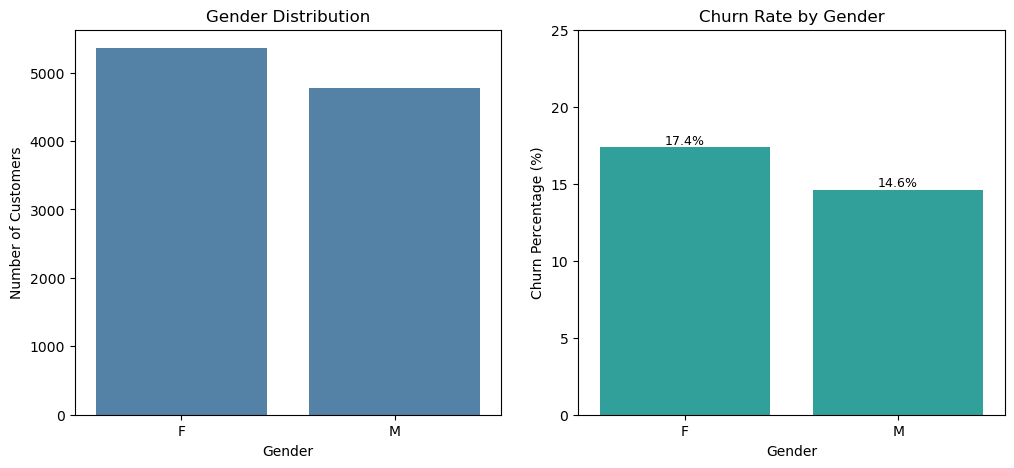

In [149]:
#gender distribution of customers
#calculate churn percentage by gender
gender_churn = pd.crosstab(
    customer_characteristics['Gender'],
    customer_characteristics['Attrition_Flag'],
    normalize='index'
)*100

#create figure
fig, axes = plt.subplots(1,2,figsize=(12,5))

#Gender Distribution
sns.countplot(
    data=customer_characteristics,
    x='Gender',
    color='steelblue',
    order=['F','M'],
    ax=axes[0]
)
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Customers')

#Churn Percentage 
sns.barplot(
    x=gender_churn.index,
    y=gender_churn[1],
    order=['F','M'],
    color='lightseagreen',
    ax=axes[1]
)
axes[1].set_title('Churn Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Churn Percentage (%)')
axes[1].set_ylim(0, 25)

#add percentage labels
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
    )
plt.subplots_adjust(wspace=0.18)
plt.show()

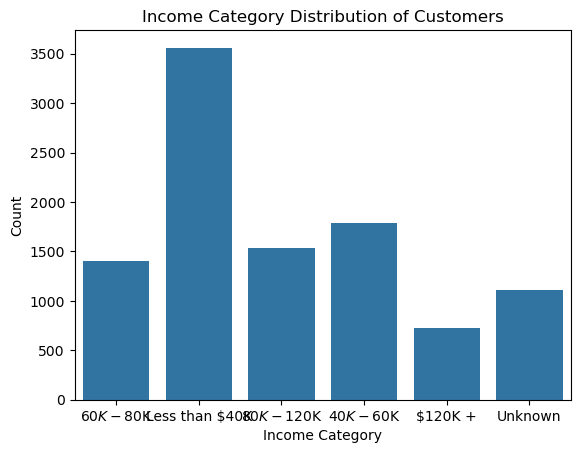

In [129]:
#income category distribution of customers
sns.countplot(data=customer_characteristics, x='Income_Category',)
plt.title('Income Category Distribution of Customers')
plt.xlabel('Income Category')
plt.ylabel('Count')     
plt.show()

In [ ]:
#checking the unknown value 
pd.crosstab(
    NewChurnModel['Income_Category'],
    NewChurnModel['Attrition_Flag'],
    normalize='index'
)*100

Attrition_Flag,0,1
Income_Category,,
$120K +,82.668501,17.331499
$40K - $60K,84.860335,15.139665
$60K - $80K,86.519258,13.480742
$80K - $120K,84.234528,15.765472
Less than $40K,82.813816,17.186184
Unknown,83.183453,16.816547


In [ ]:
#how many are unknown 
NewChurnModel['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

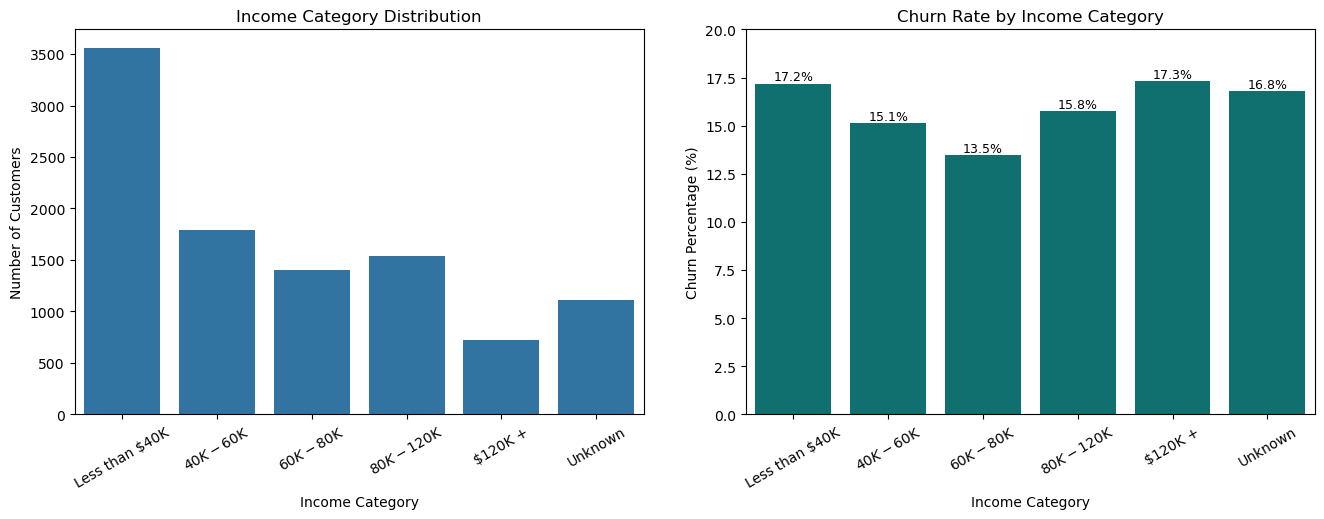

In [146]:
#fix income ordering for better visualization - will come back to this later
income_order=['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']

#calculate churn percentages
income_churn = pd.crosstab(
    NewChurnModel['Income_Category'],
    NewChurnModel['Attrition_Flag'],
    normalize='index'
)*100

fig, axes = plt.subplots(1,2,figsize=(16,5))

#Graph 1: Count of customers by income category
sns.countplot(
    data=customer_characteristics, 
    x='Income_Category',
    order=income_order, 
    ax=axes[0]
)

axes[0].set_title('Income Category Distribution')
axes[0].set_xlabel('Income Category')
axes[0].set_ylabel('Number of Customers')   
axes[0].tick_params(axis='x', rotation=30)

#Graph 2: Churn percentage by income category

sns.barplot(
    x=income_churn.index, 
    y=income_churn[1], 
    order=income_order, 
    ax=axes[1],
    color='teal'
)
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )
axes[1].set_title('Churn Rate by Income Category')
axes[1].set_xlabel('Income Category')
axes[1].set_ylabel('Churn Percentage (%)')
axes[1].set_ylim(0, 20)  # Set y-axis limit to 20%
axes[1].tick_params(axis='x', rotation=30)

plt.subplots_adjust(wspace=0.18)
plt.show()

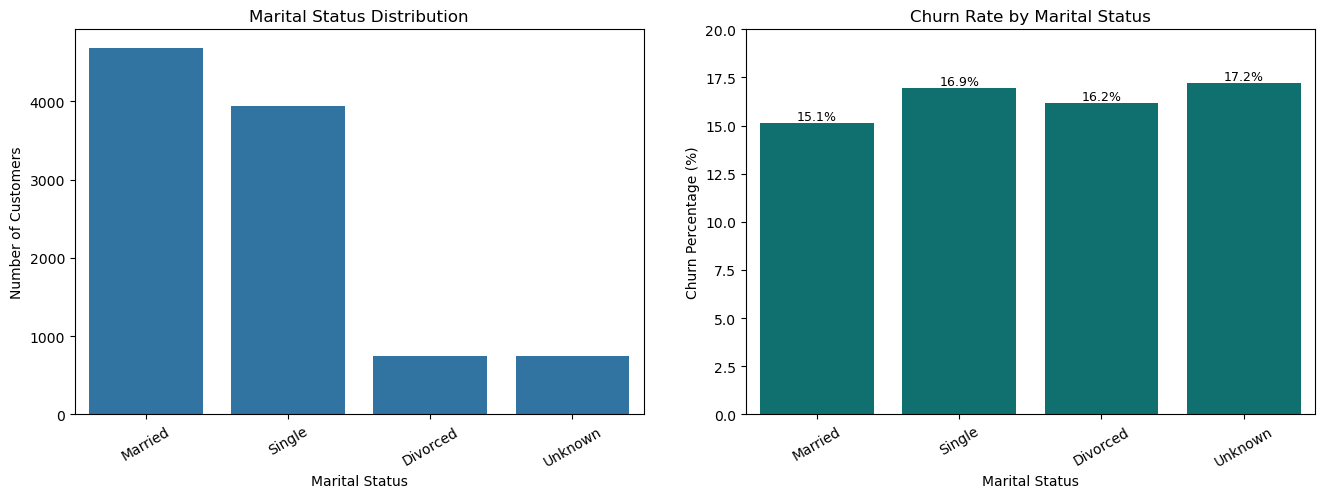

In [145]:
#marital status churn
marital_churn = pd.crosstab(
    customer_characteristics['Marital_Status'],
    customer_characteristics['Attrition_Flag'],
    normalize='index'
) *100

#order marital status
marital_order = [
    'Married',
    'Single',
    'Divorced',
    'Unknown'
]

#create figure 
fig, axes = plt.subplots(1,2,figsize=(16,5))

#martial graph - count
sns.countplot(
    data=customer_characteristics,
    x='Marital_Status',
    ax=axes[0],
    order=marital_order
)
axes[0].set_title('Marital Status Distribution')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

#churn graph
sns.barplot(
    x=marital_churn.index,
    y=marital_churn[1],
    ax=axes[1],
    order=marital_order,
    color='teal'
)

for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )
axes[1].set_title('Churn Rate by Marital Status')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Churn Percentage (%)')
axes[1].set_ylim(0, 20)  # Set y-axis limit to 20%
axes[1].tick_params(axis='x', rotation=30)

plt.subplots_adjust(wspace=0.18)
plt.show()


In [156]:
#education level graphs
#education churn
education_churn = pd.crosstab(
    customer_characteristics['Education_Level'],
    customer_characteristics['Attrition_Flag'],
    normalize='index'
) *100

#order for graph 
education_order=[
    'Uneducated',
    'High School',
    'College',
    'Graduate',
    'Post-Graduate',
    'Doctorate',
    'Unknown'
]
#create figure 
fig, axes = plt.subplots(1,2,figsize=(16,5))

#graph 1 - count
sns.countplot(
    data=customer_characteristics
    x='Education_Level',
    ax=axes[0],
    order=education_order
)

axes[0].set_title('Education Level Distribution')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

#graph 2 - churn 
sns.barplot(
    x=education_churn.index
    y=education_churn[1],
    ax=axes[1],
    order=education_order,
    color='teal'
)
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

axes[1].set_title('Churn Rate by Education Level')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Churn Percentage (%)')
axes[1].set_ylim(0, 20)  # Set y-axis limit to 20%
axes[1].tick_params(axis='x', rotation=30)

plt.subplots_adjust(wspace=0.18)
plt.show()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2593634421.py, line 24)